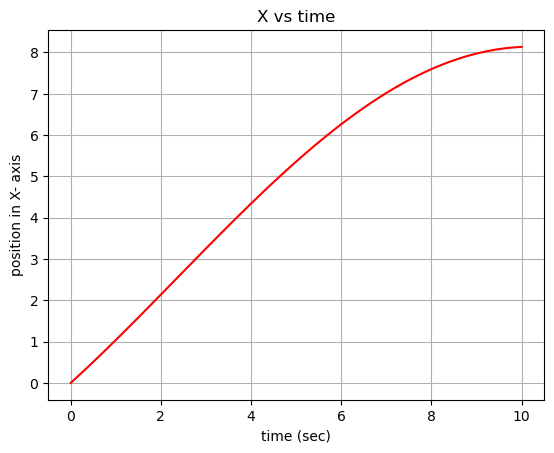

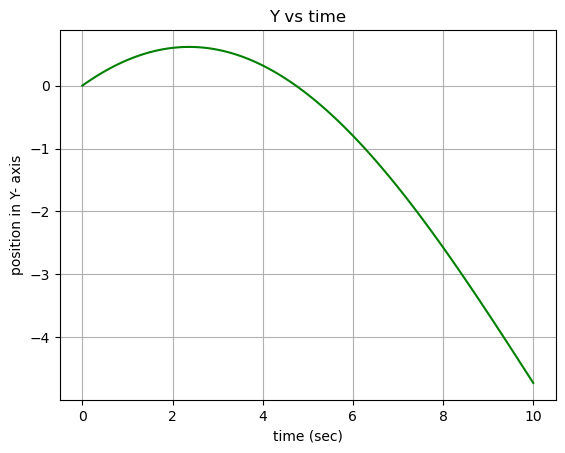

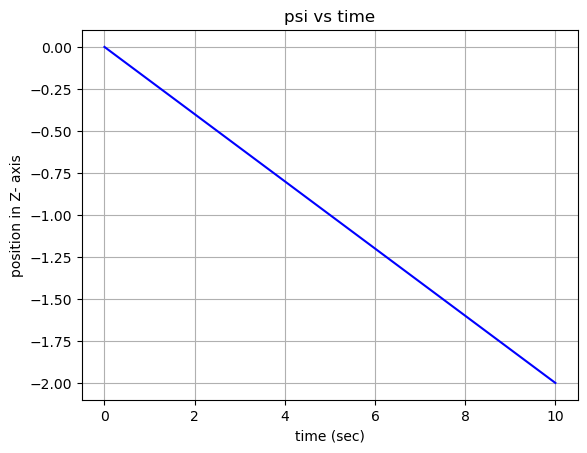

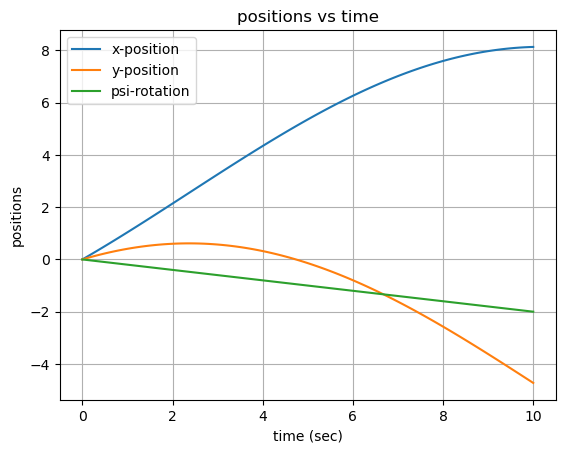

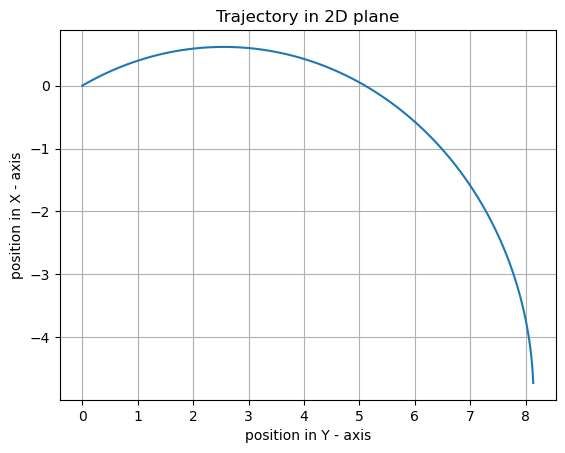

In [41]:
import numpy as np
# time duration
dt = 0.1
ts = 10 
t = np.arange(0,ts+dt,dt)
# initial conditions
x0=0
y0=0
psi0=0

# converting initial conditions into vector
eta0 = np.array([x0, y0, psi0])
eta0 = eta0.reshape(3, 1)
eta0=eta0.flatten()

#generating a matrix eta to store postition of body for each samples of second
eta = np.zeros((3,len(t)+1))
eta[:,0]=eta0


zeta = np.zeros((3,len(t)))
eta_dot = np.zeros((3,len(t)))
for i in  range(len(t)):
    psi = eta[2,i] # psi = rotation of body which is equal to this relation

    #defining velocities
    u = 1
    v = 0.5
    r= 0.2

    #velocity vector
    zeta[:,i]=[u,v,r]

    #Jacobian matrix
    j_psi = np.array([[np.cos(psi),-np.sin(psi),0]
                      ,[np.sin(psi),np.cos(psi),0]
                      ,[0,0,1]])
    
    #eta_dot for each sample of time 
    eta_dot[:,i] = j_psi @ zeta[:,i]

    #need eta for next second for the value of psi
    eta[:,i+1]=eta[:,i]+dt*eta_dot[:,i]

#removing extra column of eta
eta = eta[:,: -1]


#plot starts
import matplotlib.pyplot as plt

plt.figure()
plt.plot(t,eta[0,:],'r-')
plt.xlabel("time (sec)")
plt.ylabel("position in X- axis")
plt.title("X vs time")
plt.grid()
plt.show()

plt.figure()
plt.plot(t,eta[1,:],'g-')
plt.xlabel("time (sec)")
plt.ylabel("position in Y- axis")
# plt.legend()
plt.title("Y vs time")
plt.grid()
plt.show()

plt.figure()
plt.plot(t,eta[2,:],'b-')
plt.xlabel("time (sec)")
plt.ylabel("position in Z- axis")
# plt.legend()
plt.title("psi vs time")
plt.grid()
plt.show()

plt.figure()
plt.plot(t,eta[0,:],label = 'x-position')
plt.plot(t,eta[1,:],label = 'y-position')
plt.plot(t,eta[2,:],label = 'psi-rotation')
plt.xlabel("time (sec)")
plt.ylabel("positions")
plt.legend()
plt.title("positions vs time")
plt.grid()
plt.show()

plt.figure()
# plt.plot(t,,label = 'x-position')
plt.plot(eta[0,:],eta[1,:])
# plt.plot(t,eta[2,:],label = 'psi-rotation')
plt.xlabel("position in Y - axis")
plt.ylabel("position in X - axis")
# plt.legend()
plt.title("Trajectory in 2D plane")
plt.grid()
plt.show()

